In [ ]:
!pip install pymoo numpy pandas matplotlib


Processing Function: ZDT1 (MGPSO)
  Trial 30/30 running...
  [Done] ZDT1 — 30 trials completed.
  Summary for ZDT1:
    IGD: Mean = 0.014225, Std = 0.005663
    HV:  Mean = 5.794654, Std = 0.036180


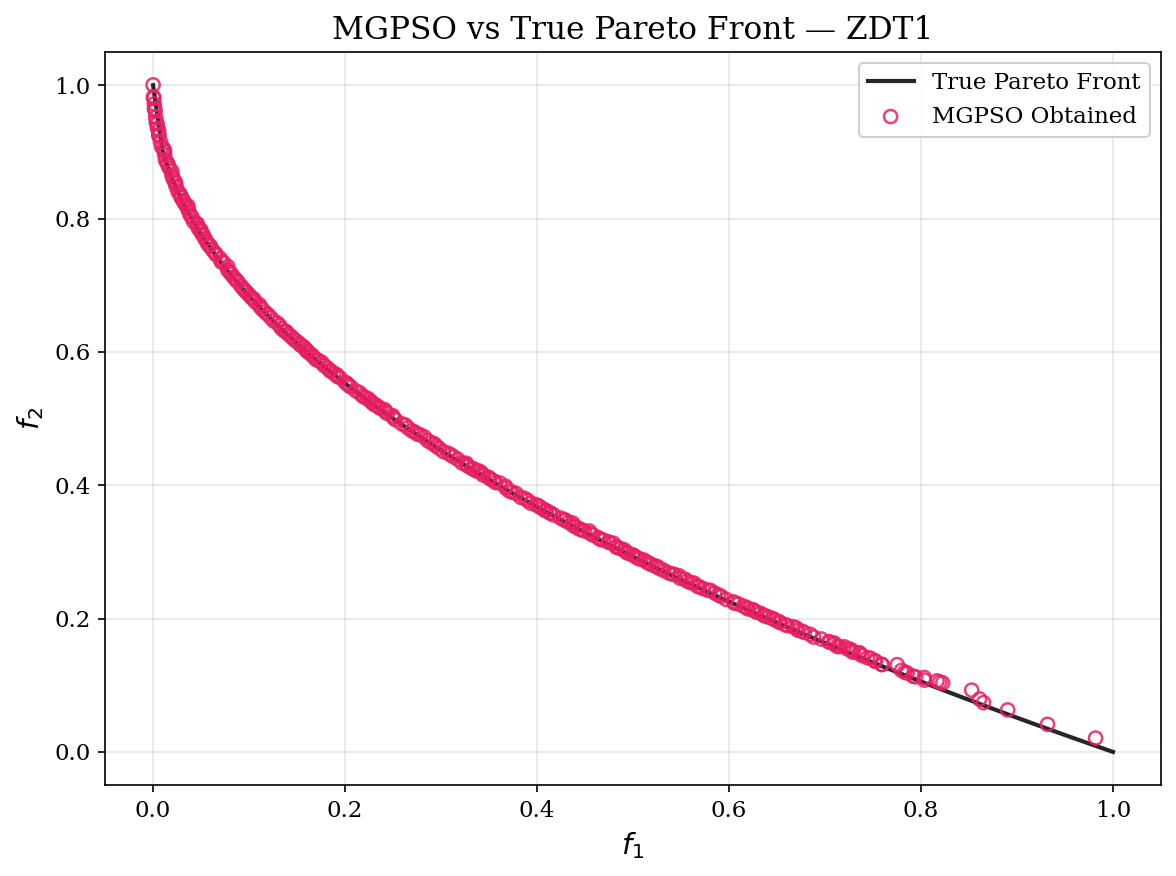


Processing Function: ZDT2 (MGPSO)
  Trial 30/30 running...
  [Done] ZDT2 — 30 trials completed.
  Summary for ZDT2:
    IGD: Mean = 0.095529, Std = 0.021229
    HV:  Mean = 4.710112, Std = 0.102754


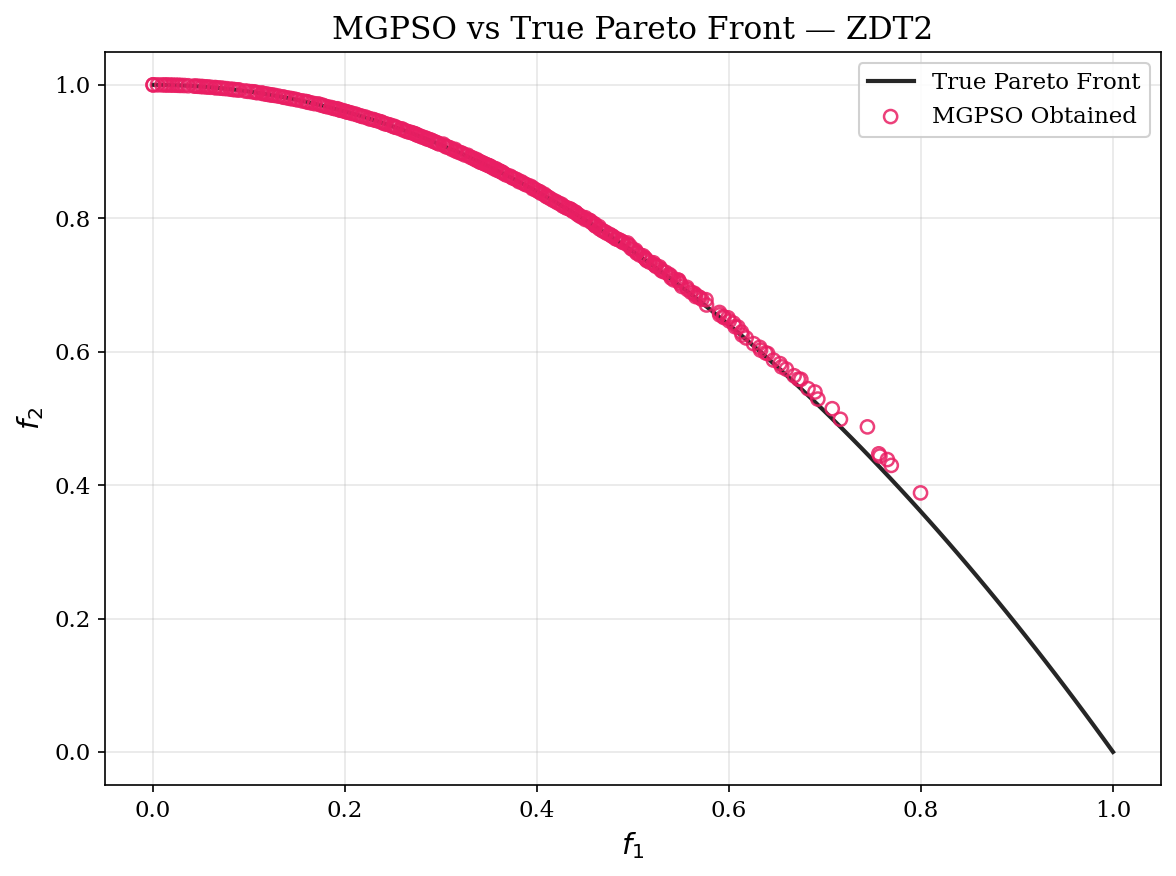


Processing Function: ZDT3 (MGPSO)
  Trial 30/30 running...
  [Done] ZDT3 — 30 trials completed.
  Summary for ZDT3:
    IGD: Mean = 0.031235, Std = 0.025579
    HV:  Mean = 7.186626, Std = 0.226005


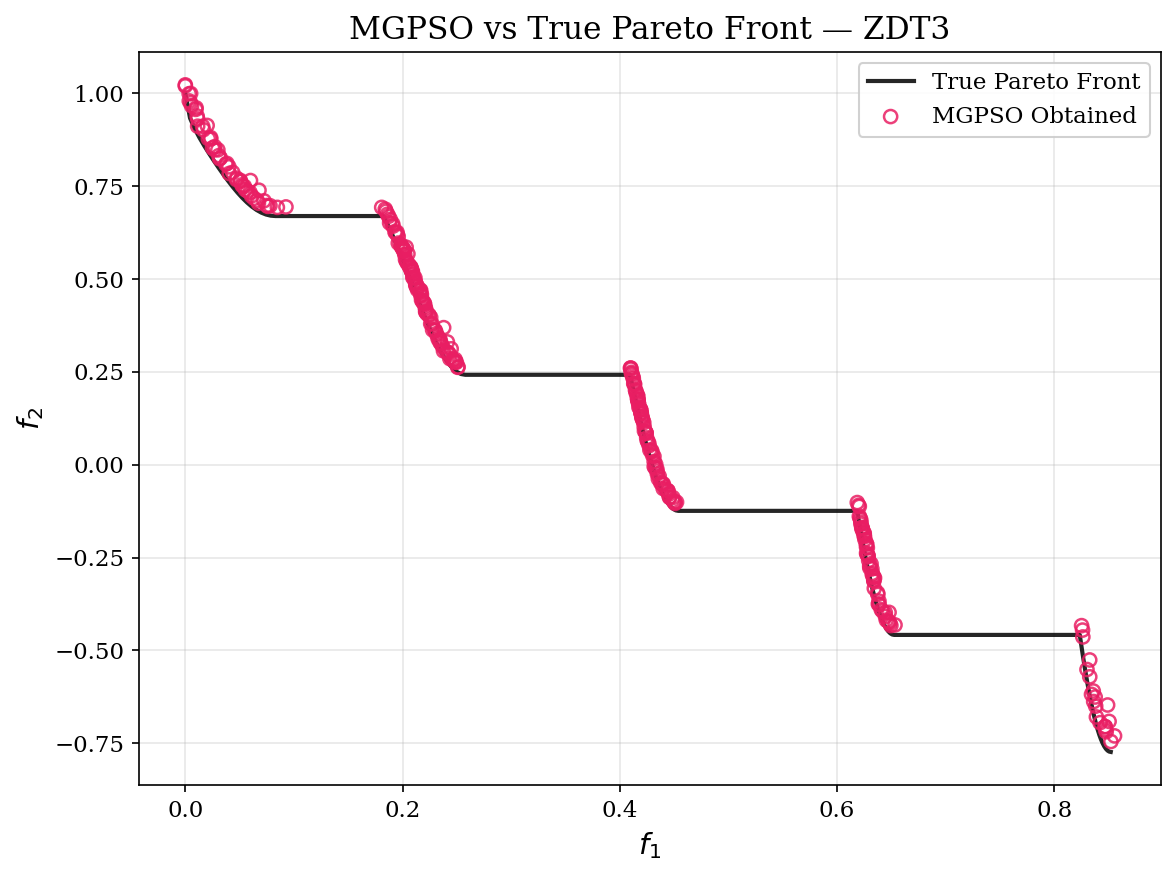


Processing Function: ZDT4 (MGPSO)
  Trial 30/30 running...
  [Done] ZDT4 — 30 trials completed.
  Summary for ZDT4:
    IGD: Mean = 17.852812, Std = 2.941757
    HV:  Mean = 0.000000, Std = 0.000000


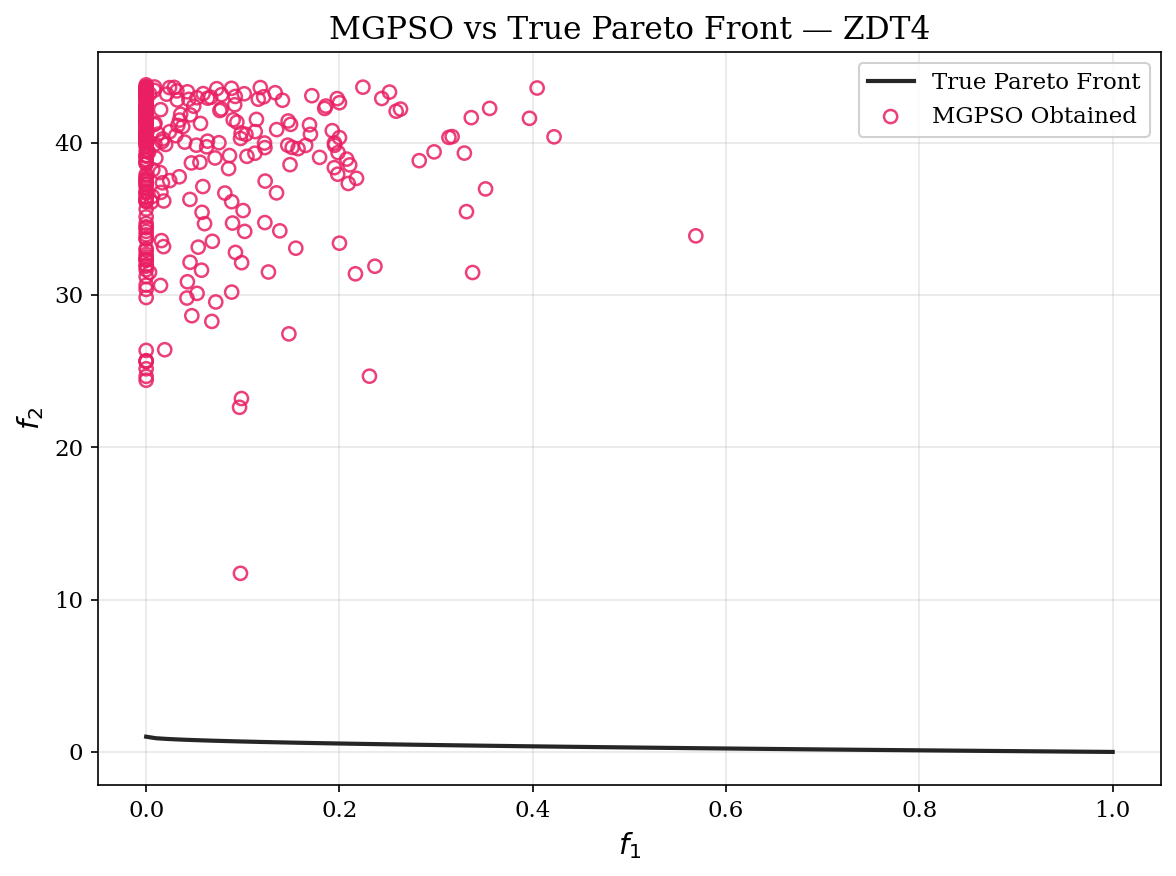


Processing Function: ZDT6 (MGPSO)
  Trial 30/30 running...
  [Done] ZDT6 — 30 trials completed.
  Summary for ZDT6:
    IGD: Mean = 0.001138, Std = 0.000091
    HV:  Mean = 5.153506, Std = 0.000025


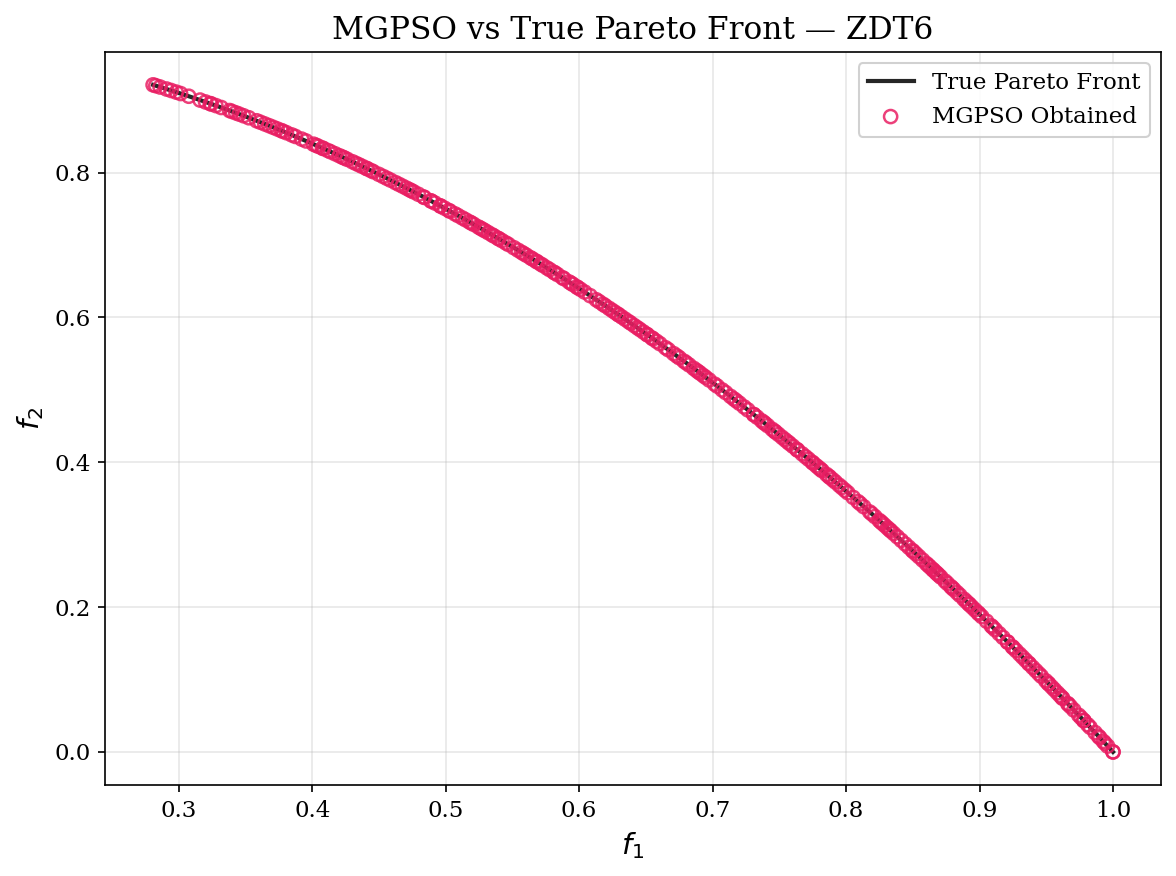


Processing Function: WFG1 (MGPSO)
  Trial 30/30 running...
  [Done] WFG1 — 30 trials completed.
  Summary for WFG1:
    IGD: Mean = 1.428306, Std = 0.017715
    HV:  Mean = 44.923587, Std = 0.541207


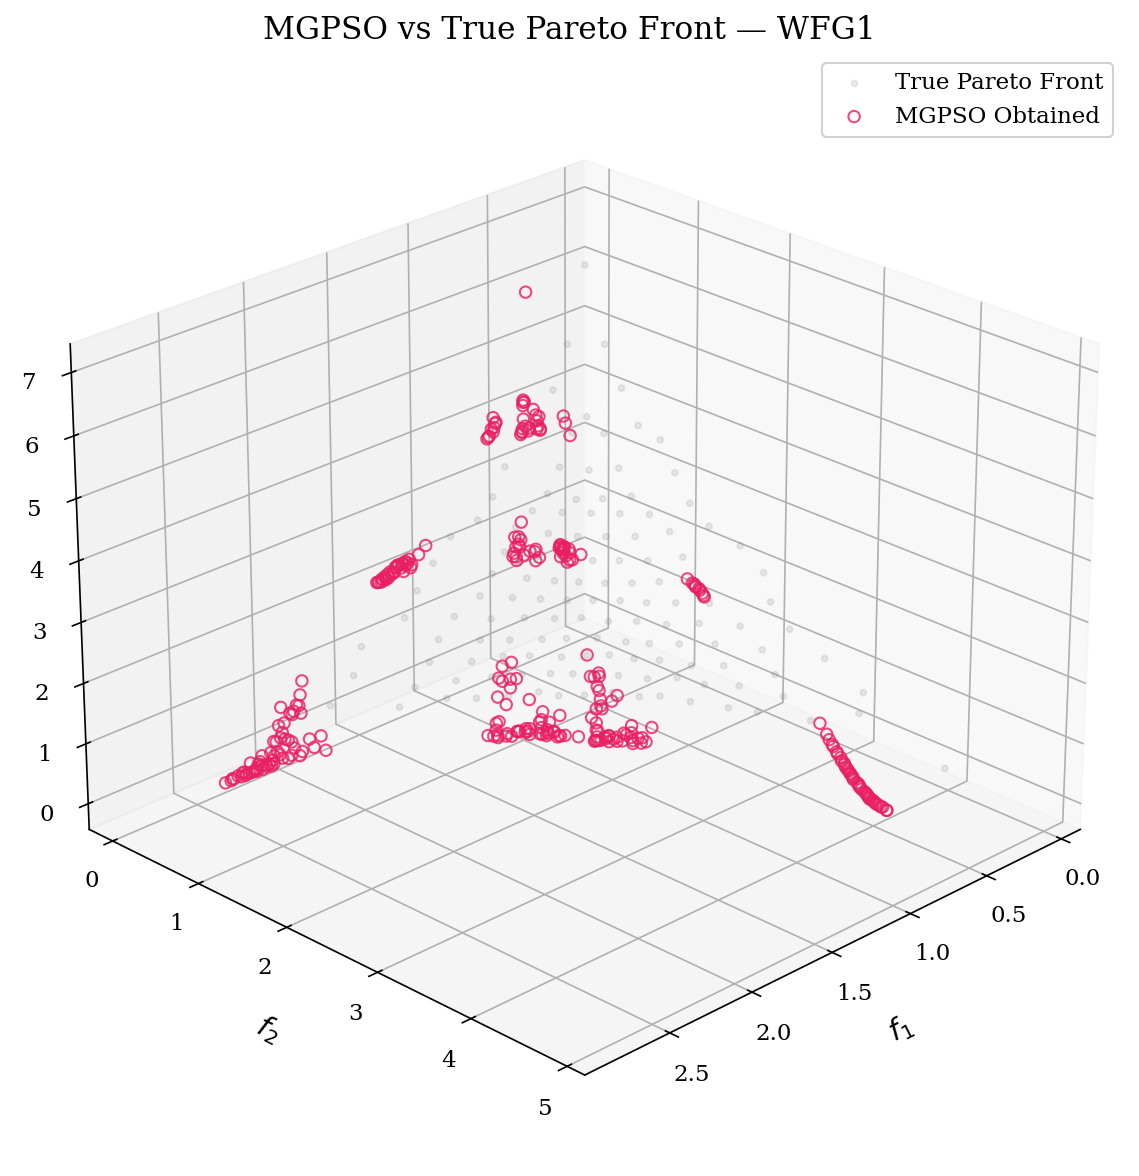


Processing Function: WFG2 (MGPSO)
  Trial 30/30 running...
  [Done] WFG2 — 30 trials completed.
  Summary for WFG2:
    IGD: Mean = 0.254314, Std = 0.016645
    HV:  Mean = 92.267981, Std = 0.430831


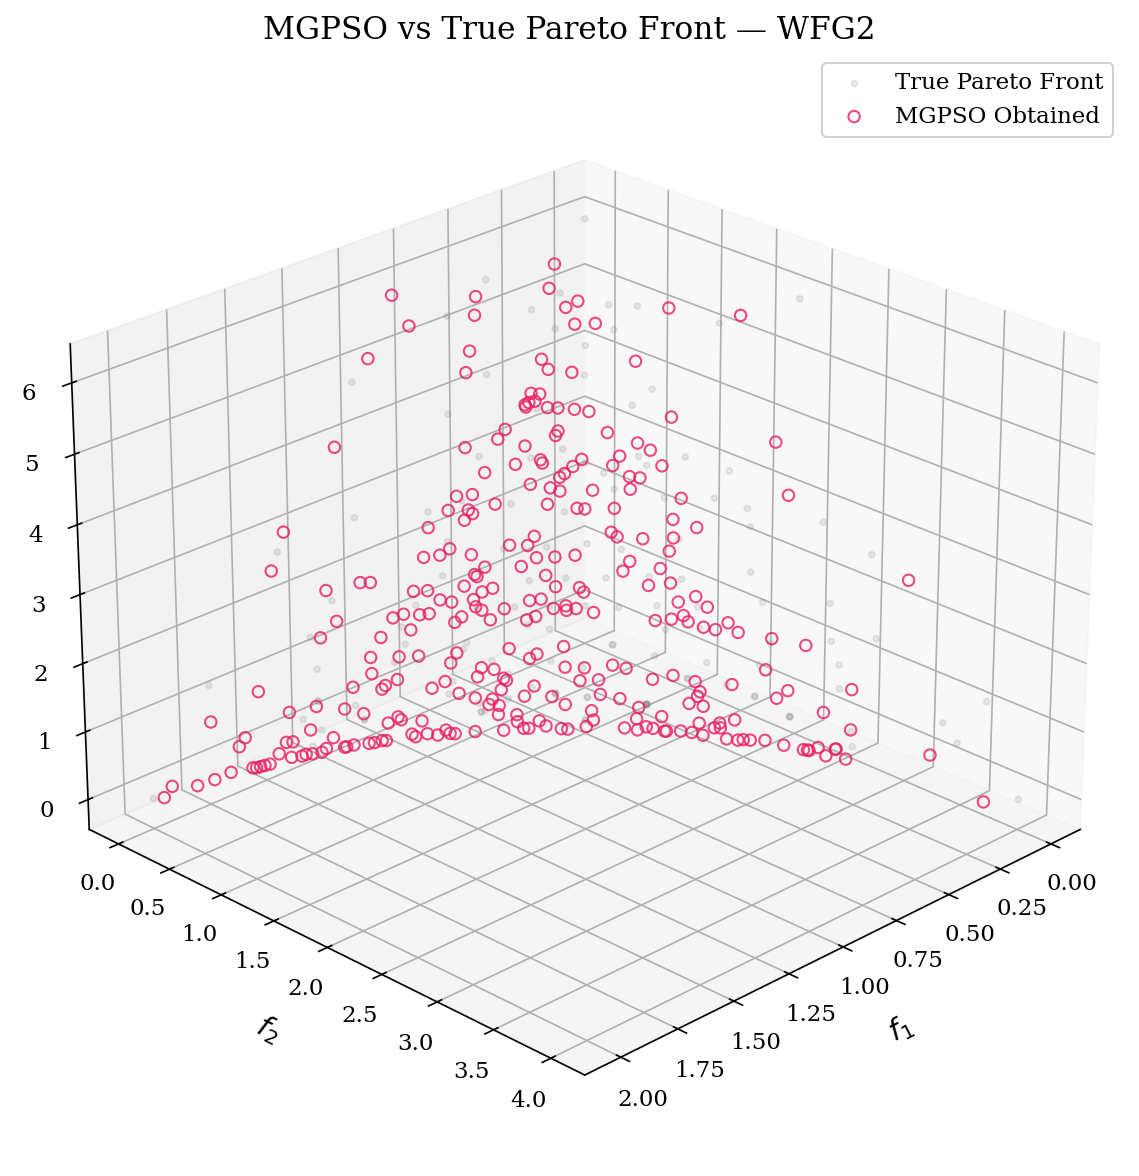


Processing Function: WFG3 (MGPSO)
  Trial 30/30 running...
  [Done] WFG3 — 30 trials completed.
  Summary for WFG3:
    IGD: Mean = 0.311164, Std = 0.015550
    HV:  Mean = 63.213778, Std = 0.685314


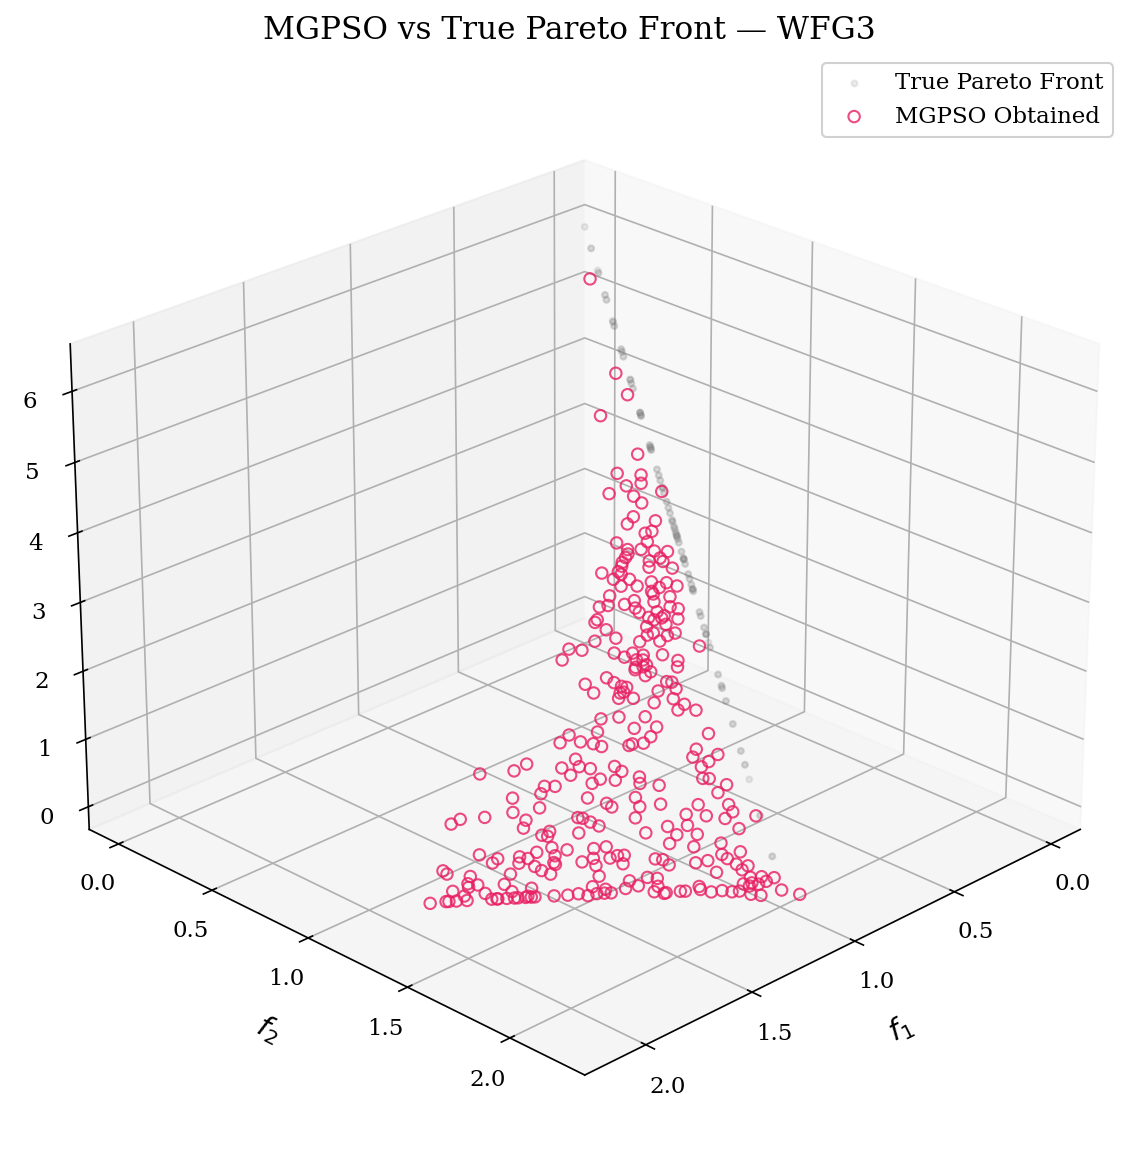


Processing Function: WFG4 (MGPSO)
  Trial 30/30 running...
  [Done] WFG4 — 30 trials completed.
  Summary for WFG4:
    IGD: Mean = 0.242411, Std = 0.008575
    HV:  Mean = 69.296253, Std = 0.447075


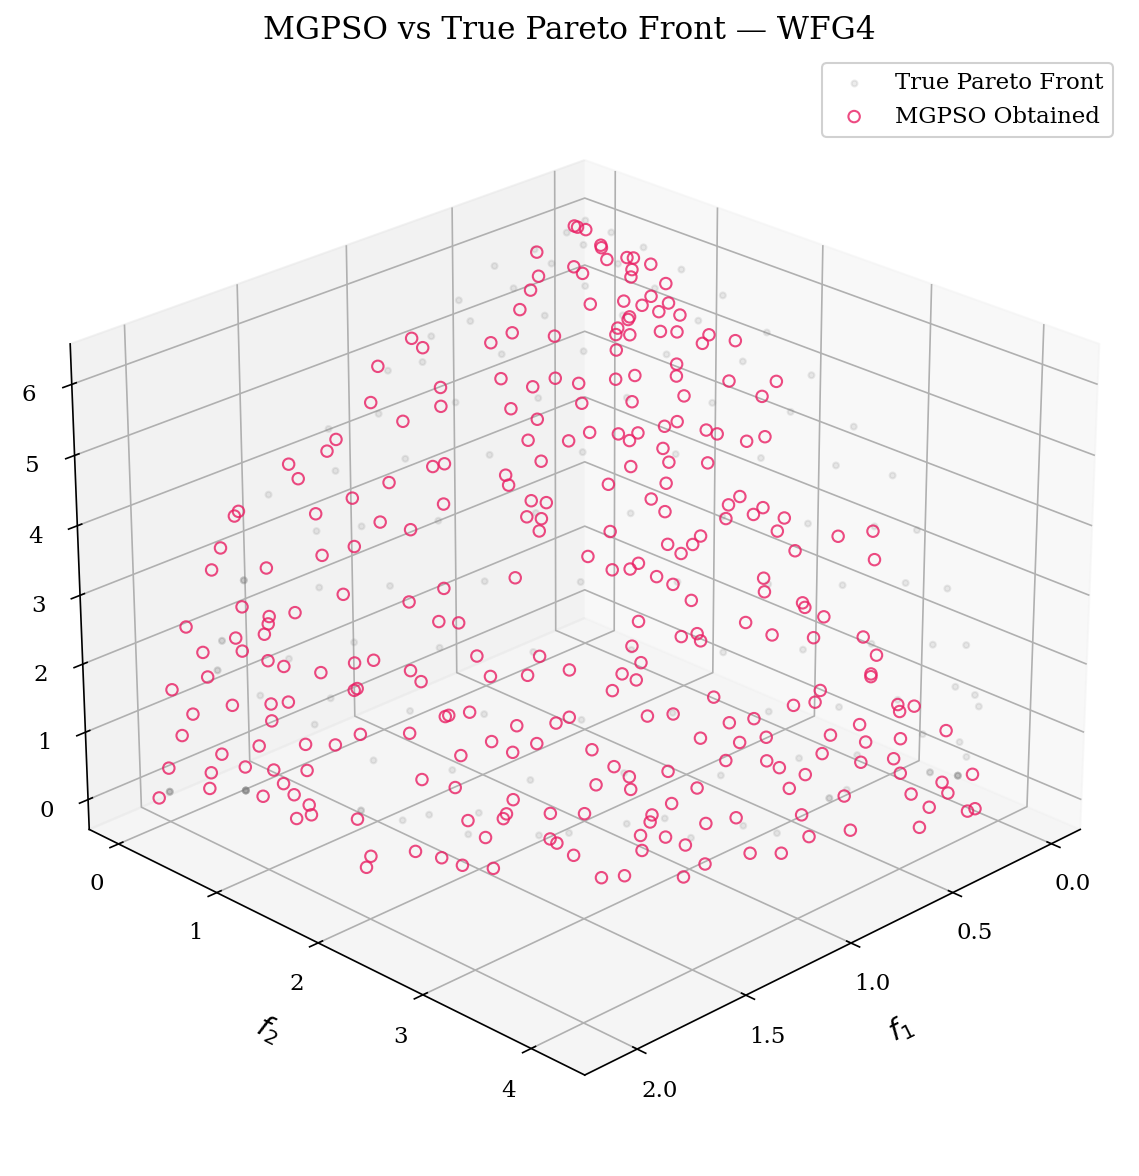


Processing Function: WFG5 (MGPSO)
  Trial 30/30 running...
  [Done] WFG5 — 30 trials completed.
  Summary for WFG5:
    IGD: Mean = 0.507113, Std = 0.150200
    HV:  Mean = 54.598011, Std = 6.091373


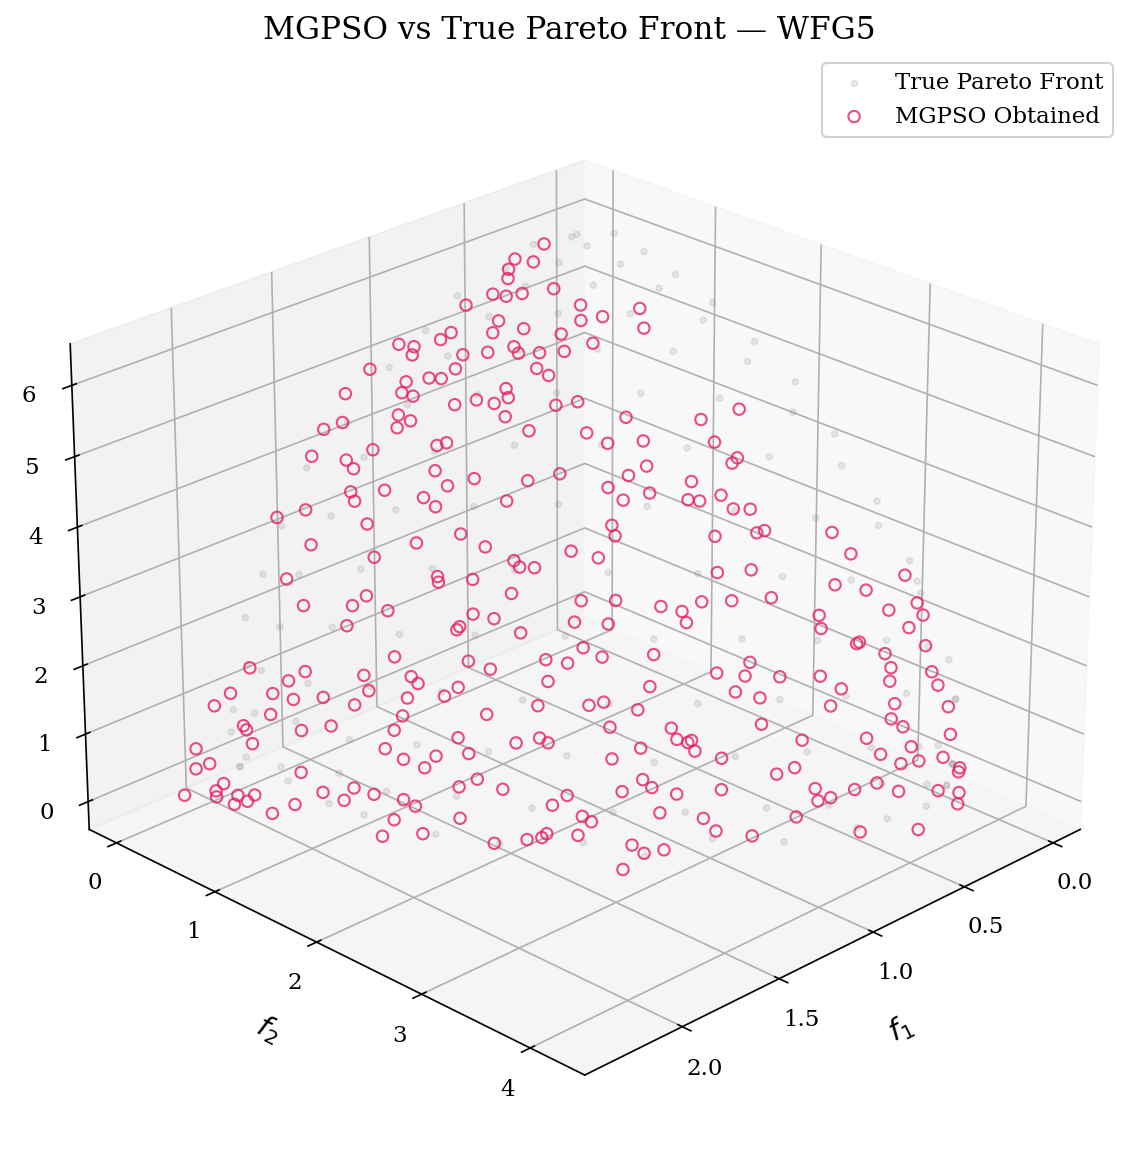


Processing Function: WFG6 (MGPSO)
  Trial 30/30 running...
  [Done] WFG6 — 30 trials completed.
  Summary for WFG6:
    IGD: Mean = 0.392126, Std = 0.017152
    HV:  Mean = 61.193219, Std = 0.975634


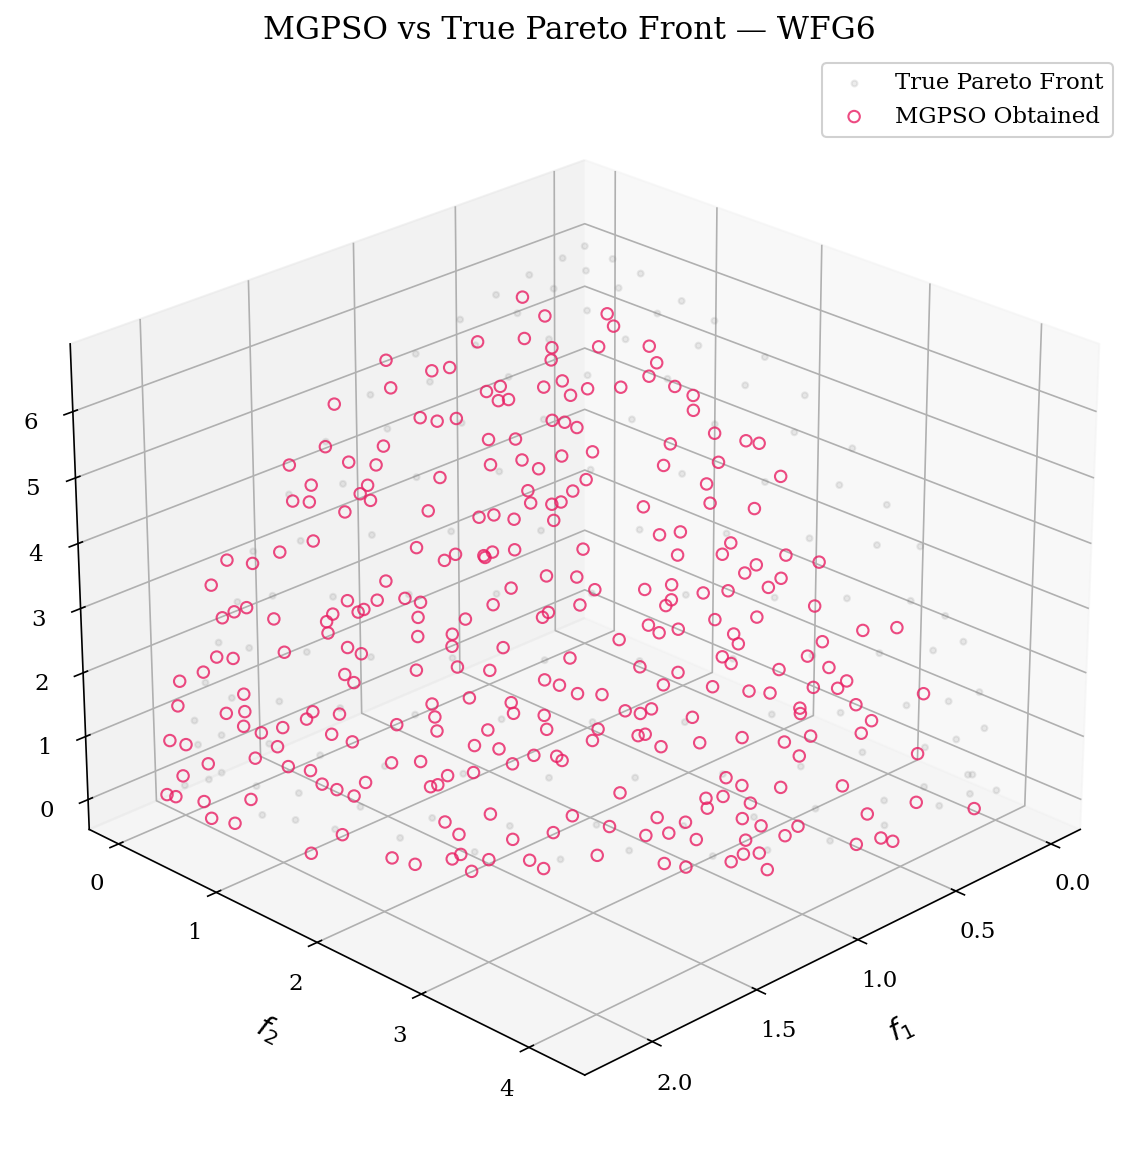


Processing Function: WFG7 (MGPSO)
  Trial 30/30 running...
  [Done] WFG7 — 30 trials completed.
  Summary for WFG7:
    IGD: Mean = 0.395577, Std = 0.004917
    HV:  Mean = 62.306128, Std = 0.234097


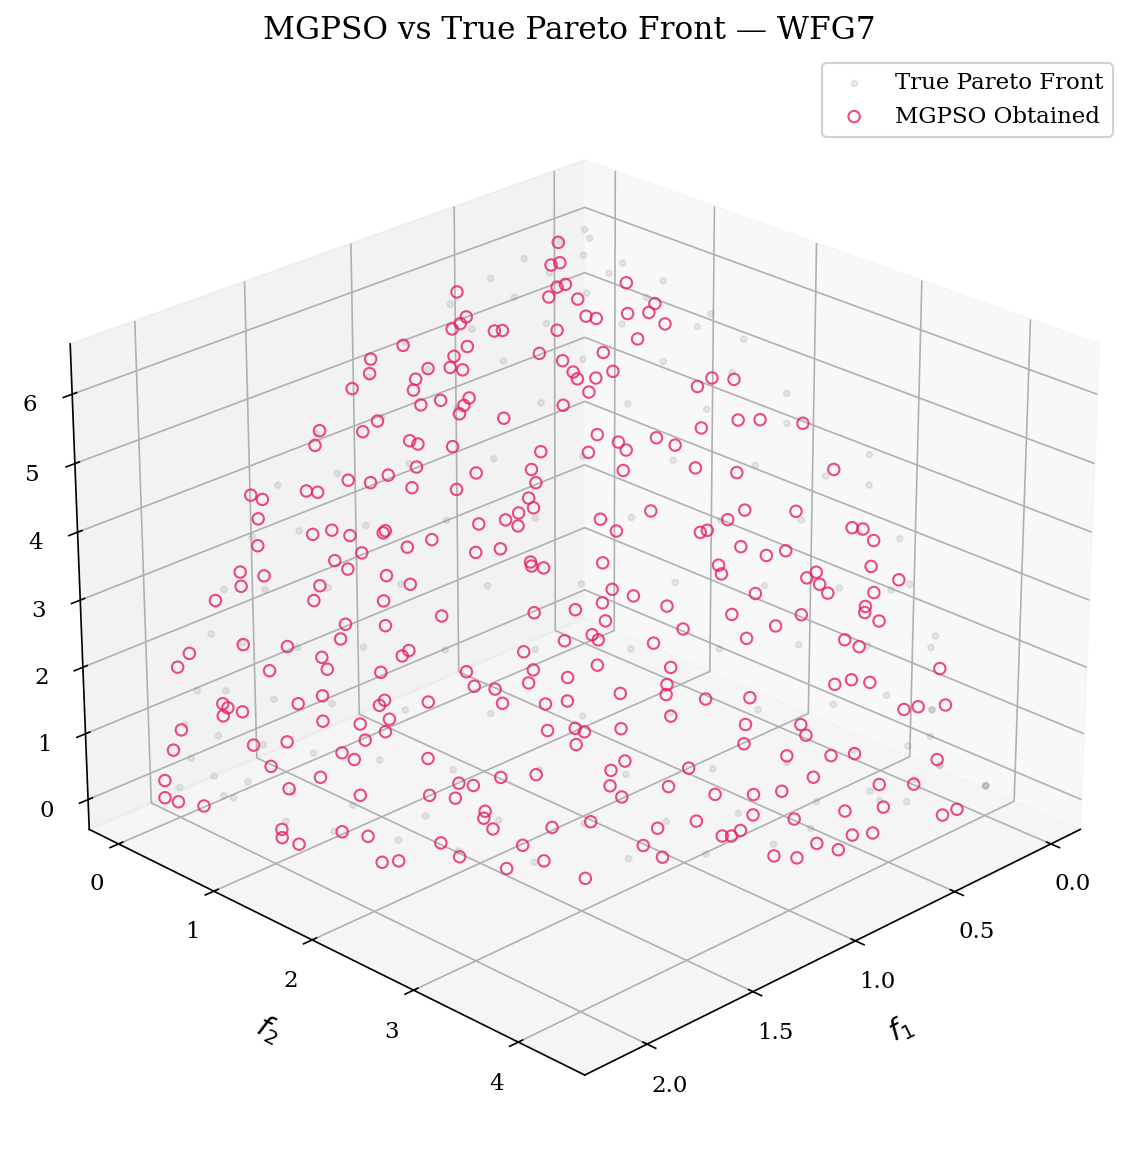


Processing Function: WFG8 (MGPSO)
  Trial 30/30 running...
  [Done] WFG8 — 30 trials completed.
  Summary for WFG8:
    IGD: Mean = 0.481346, Std = 0.014480
    HV:  Mean = 56.867701, Std = 0.794416


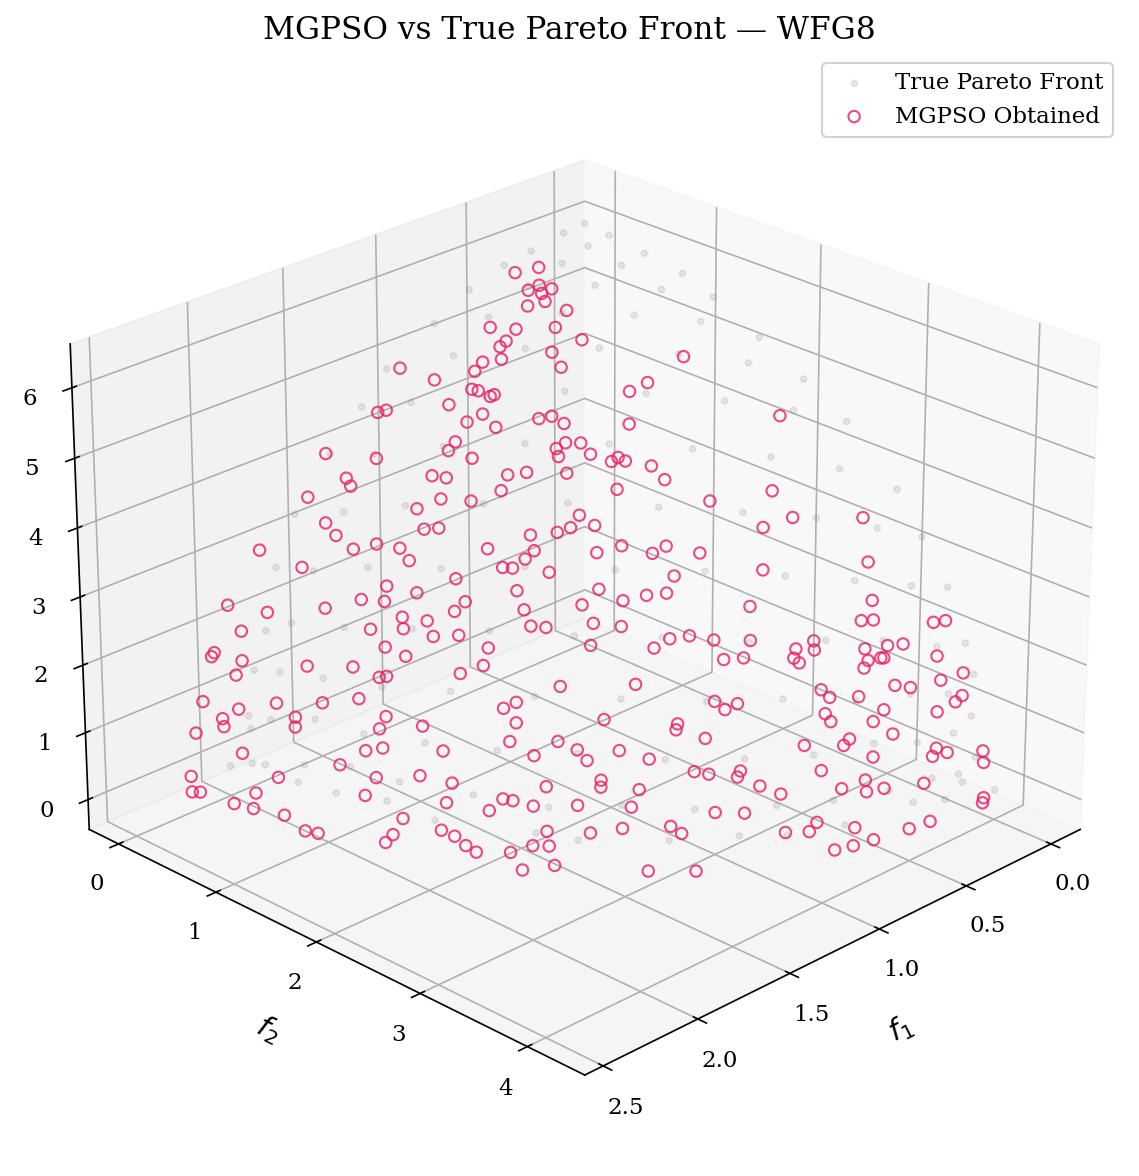


Processing Function: WFG9 (MGPSO)
  Trial 30/30 running...
  [Done] WFG9 — 30 trials completed.
  Summary for WFG9:
    IGD: Mean = 0.276113, Std = 0.016701
    HV:  Mean = 66.289111, Std = 0.888972


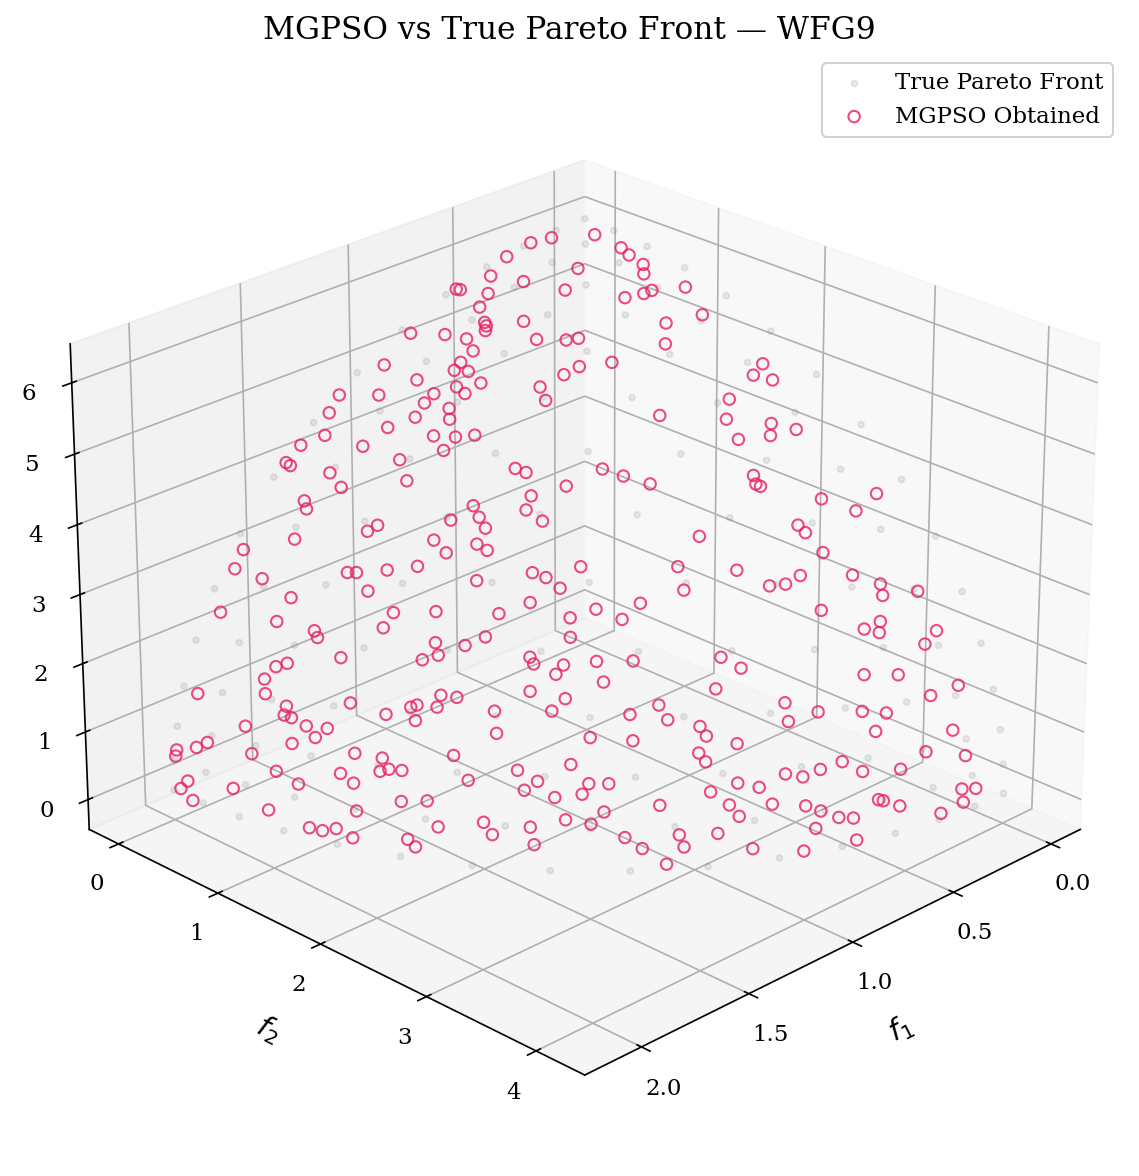


FINAL SUMMARY TABLE — MGPSO
Function  IGD_Mean  IGD_Std   HV_Mean   HV_Std
    ZDT1  0.014225 0.005663  5.794654 0.036180
    ZDT2  0.095529 0.021229  4.710112 0.102754
    ZDT3  0.031235 0.025579  7.186626 0.226005
    ZDT4 17.852812 2.941757  0.000000 0.000000
    ZDT6  0.001138 0.000091  5.153506 0.000025
    WFG1  1.428306 0.017715 44.923587 0.541207
    WFG2  0.254314 0.016645 92.267981 0.430831
    WFG3  0.311164 0.015550 63.213778 0.685314
    WFG4  0.242411 0.008575 69.296253 0.447075
    WFG5  0.507113 0.150200 54.598011 6.091373
    WFG6  0.392126 0.017152 61.193219 0.975634
    WFG7  0.395577 0.004917 62.306128 0.234097
    WFG8  0.481346 0.014480 56.867701 0.794416
    WFG9  0.276113 0.016701 66.289111 0.888972


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pymoo.core.population import Population
from pymoo.problems import get_problem
from pymoo.indicators.igd import IGD
from pymoo.indicators.hv import HV
from pymoo.algorithms.moo.nsga2 import RankAndCrowdingSurvival

# ============================================================
# MODEL 2: MGPSO (Multi-Guide PSO)
# ============================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3
})

ALGO_NAME = "MGPSO"
N_PARTICLES = 150
ARCHIVE_SIZE = 300
N_RUNS = 30

# --- Reusable Functions ---

def polynomial_mutation(X, xl, xu, eta=20):
    """Polynomial mutation for maintaining search diversity."""
    n, d = X.shape
    prob = 1.0 / d
    mut_mask = np.random.random((n, d)) < prob
    delta = xu - xl
    delta = np.where(delta < 1e-10, 1e-10, delta)
    u = np.random.random((n, d))
    delta1 = np.clip((X - xl) / delta, 0, 1)
    delta2 = np.clip((xu - X) / delta, 0, 1)
    pow_val = 1.0 / (eta + 1.0)
    mask_low = u <= 0.5
    xy = 1.0 - delta1
    val = 2.0 * u + (1.0 - 2.0 * u) * np.power(np.clip(xy, 0, None), eta + 1.0)
    deltaq_low = np.power(np.clip(val, 0, None), pow_val) - 1.0
    xy = 1.0 - delta2
    val = 2.0 * (1.0 - u) + 2.0 * (u - 0.5) * np.power(np.clip(xy, 0, None), eta + 1.0)
    deltaq_high = 1.0 - np.power(np.clip(val, 0, None), pow_val)
    deltaq = np.where(mask_low, deltaq_low, deltaq_high)
    X_mutated = X + deltaq * delta * mut_mask
    return np.clip(X_mutated, xl, xu)

def update_archive(problem, archive, new_pop, max_size=ARCHIVE_SIZE):
    """Updates external archive using pymoo's RankAndCrowding survival."""
    if archive is None or len(archive) == 0:
        combined = new_pop
    else:
        combined = Population.merge(archive, new_pop)
    survival = RankAndCrowdingSurvival()
    return survival.do(problem, combined, n_survive=min(len(combined), max_size))

def tournament_selection_archive(archive, size=5):
    """
    Selects the least crowded guide from the archive using tournament selection.
    Increased tournament size (3->5) for better diversity pressure.
    """
    if len(archive) == 0:
        return None
    indices = np.random.choice(len(archive), min(size, len(archive)), replace=False)
    candidates = archive[indices]
    cds = candidates.get("crowding")
    if cds is not None:
        cds_safe = np.nan_to_num(cds, nan=0.0, posinf=1e6)
        best_idx = np.argmax(cds_safe)
        return candidates[best_idx].x
    else:
        return candidates[np.random.randint(len(candidates))].x

# --- Main MGPSO Logic ---

def run_mgpso(problem_obj, n_particles=N_PARTICLES, n_gen=300, seed=0):
    np.random.seed(seed)
    xl, xu = problem_obj.bounds()
    vmax = 0.2 * (xu - xl)  # Velocity clamping
    
    # Fixed Parameters per MGPSO
    w = 0.7298  # Constriction factor-based w
    c1, c2, c3 = 1.49618, 1.49618, 1.49618
    lambd = 0.5  # Archive trade-off coefficient
    
    # Initialize Particles
    X = np.random.uniform(xl, xu, (n_particles, problem_obj.n_var))
    V = np.random.uniform(-0.1 * (xu - xl), 0.1 * (xu - xl), (n_particles, problem_obj.n_var))
    
    # Initial Evaluation
    F = problem_obj.evaluate(X)
    pop = Population.new("X", X, "F", F)
    
    # Setup Personal Bests and Archive
    pbest_X = np.copy(X)
    pbest_F = np.copy(F)
    archive = Population()
    archive = update_archive(problem_obj, archive, pop)
    
    for gen in range(n_gen):
        for i in range(n_particles):
            # 1. Neighborhood Guide (Ring Topology radius 3)
            nb_idx = np.arange(i - 3, i + 4) % n_particles
            lbest_idx_in_nb = np.argmin(np.sum(pbest_F[nb_idx], axis=1))
            y_hat = pbest_X[nb_idx[lbest_idx_in_nb]]
            
            # 2. Global Archive Guide (Tournament Selection)
            a_hat = tournament_selection_archive(archive, size=5)
            if a_hat is None: a_hat = y_hat
            
            # 3. Velocity Update (MGPSO Equation 4)
            r1 = np.random.random(problem_obj.n_var)
            r2 = np.random.random(problem_obj.n_var)
            r3 = np.random.random(problem_obj.n_var)
            
            term_pbest = c1 * r1 * (pbest_X[i] - X[i])
            term_neigh = lambd * c2 * r2 * (y_hat - X[i])
            term_arch  = (1 - lambd) * c3 * r3 * (a_hat - X[i])
            
            V[i] = w * V[i] + term_pbest + term_neigh + term_arch
            V[i] = np.clip(V[i], -vmax, vmax)  # Velocity clamping
            
            # 4. Position Update & Clipping
            X[i] = np.clip(X[i] + V[i], xl, xu)
            
        # Apply mutation
        X = polynomial_mutation(X, xl, xu, eta=20)
        
        # Evaluation
        F = problem_obj.evaluate(X)
        pop = Population.new("X", X, "F", F)
        
        # PBest Update (Non-domination with random tie-break)
        for i in range(n_particles):
            if np.all(F[i] <= pbest_F[i]) and np.any(F[i] < pbest_F[i]):
                pbest_X[i] = np.copy(X[i])
                pbest_F[i] = np.copy(F[i])
            elif not (np.all(pbest_F[i] <= F[i]) and np.any(pbest_F[i] < F[i])):
                if np.random.random() < 0.5:
                    pbest_X[i] = np.copy(X[i])
                    pbest_F[i] = np.copy(F[i])
                
        # Archive Management
        archive = update_archive(problem_obj, archive, pop)

    return archive

# --- Publication-Quality Plotting ---

def plot_pareto_comparison_2d(pf, obtained_F, algo_name, func_name, output_path, color='#E91E63'):
    fig, ax = plt.subplots(figsize=(8, 6))
    if pf is not None:
        sorted_pf = pf[pf[:, 0].argsort()]
        ax.plot(sorted_pf[:, 0], sorted_pf[:, 1], color='black', lw=2.0, 
                label='True Pareto Front', alpha=0.85, zorder=5)
    ax.scatter(obtained_F[:, 0], obtained_F[:, 1], facecolor='none', 
              edgecolor=color, s=40, linewidths=1.2, 
              label=f'{algo_name} Obtained', alpha=0.85, zorder=10)
    ax.set_xlabel(r'$f_1$')
    ax.set_ylabel(r'$f_2$')
    ax.set_title(f'{algo_name} vs True Pareto Front — {func_name}')
    ax.legend(loc='best', framealpha=0.9)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

def plot_pareto_comparison_3d(pf, obtained_F, algo_name, func_name, output_path, color='#E91E63'):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    if pf is not None:
        ax.scatter(pf[:, 0], pf[:, 1], pf[:, 2], c='gray', s=8, 
                  label='True Pareto Front', alpha=0.15, zorder=1)
    ax.scatter(obtained_F[:, 0], obtained_F[:, 1], obtained_F[:, 2], 
             facecolor='none', edgecolor=color, s=30, linewidths=1.0,
             label=f'{algo_name} Obtained', alpha=0.8, zorder=10)
    ax.set_xlabel(r'$f_1$', labelpad=10)
    ax.set_ylabel(r'$f_2$', labelpad=10)
    ax.set_zlabel(r'$f_3$', labelpad=10)
    ax.set_title(f'{algo_name} vs True Pareto Front — {func_name}')
    ax.legend(loc='best', framealpha=0.9)
    ax.view_init(elev=25, azim=45)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# --- Experiment Execution ---

def main():
    benchmarks = ["zdt1", "zdt2", "zdt3", "zdt4", "zdt6", 
                  "wfg1", "wfg2", "wfg3", "wfg4", "wfg5", "wfg6", "wfg7", "wfg8", "wfg9"]
    
    all_results = []
    
    for b_name in benchmarks:
        print(f"\n{'='*60}")
        print(f"Processing Function: {b_name.upper()} ({ALGO_NAME})")
        print(f"{'='*60}")
        output_dir = f"./results/{ALGO_NAME}/{b_name}/"
        os.makedirs(output_dir, exist_ok=True)
        
        is_wfg = b_name.lower().startswith("wfg")
        if is_wfg:
            problem = get_problem(b_name, n_var=24, n_obj=3, k=4)
        else:
            problem = get_problem(b_name)
        
        n_gen = 400 if is_wfg else 300
        if b_name.lower() == 'zdt4':
            n_gen = 500
            
        pf = problem.pareto_front()
        
        if is_wfg:
            ref_point = np.array([3.0, 5.0, 7.0])
        else:
            ref_point = np.ones(problem.n_obj) * 2.5
        
        run_results = []
        best_igd = np.inf
        best_F = None
        
        for run in range(N_RUNS):
            print(f"  Trial {run + 1}/{N_RUNS} running...", end="\r")
            res_archive = run_mgpso(problem, n_gen=n_gen, seed=run)
            F = res_archive.get("F")
            
            if pf is not None:
                igd = IGD(pf).do(F)
                hv = HV(ref_point=ref_point).do(F)
            else:
                igd, hv = np.nan, np.nan
                
            run_results.append({"run": run + 1, "IGD": igd, "HV": hv})
            
            if igd < best_igd:
                best_igd = igd
                best_F = F.copy()
            
        print(f"\n  [Done] {b_name.upper()} — {N_RUNS} trials completed.")
        
        df = pd.DataFrame(run_results)
        df.to_csv(f"{output_dir}metrics.csv", index=False)
        
        igd_mean, igd_std = df['IGD'].mean(), df['IGD'].std()
        hv_mean, hv_std = df['HV'].mean(), df['HV'].std()
        
        print(f"  Summary for {b_name.upper()}:")
        print(f"    IGD: Mean = {igd_mean:.6f}, Std = {igd_std:.6f}")
        print(f"    HV:  Mean = {hv_mean:.6f}, Std = {hv_std:.6f}")
        
        all_results.append({
            'Function': b_name.upper(),
            'IGD_Mean': igd_mean, 'IGD_Std': igd_std,
            'HV_Mean': hv_mean, 'HV_Std': hv_std
        })
        
        if problem.n_obj == 2:
            plot_pareto_comparison_2d(pf, best_F, ALGO_NAME, b_name.upper(),
                                     f"{output_dir}pareto_front_comparison.png", color='#E91E63')
        else:
            plot_pareto_comparison_3d(pf, best_F, ALGO_NAME, b_name.upper(),
                                     f"{output_dir}pareto_front_comparison.png", color='#E91E63')
    
    print(f"\n{'='*80}")
    print(f"FINAL SUMMARY TABLE — {ALGO_NAME}")
    print(f"{'='*80}")
    summary_df = pd.DataFrame(all_results)
    summary_df.to_csv(f"./results/{ALGO_NAME}/summary.csv", index=False)
    print(summary_df.to_string(index=False))

if __name__ == "__main__":
    main()